# Volatility Modeling

In this stage, we model conditional volatility using ARCH and GARCH models.

Objectives:
1. Model time-varying volatility
2. Capture volatility clustering
3. Forecast future volatility
4. Compare volatility dynamics across assets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [3]:
!pip install arch

  Using cached arch-8.0.0-cp313-cp313-win_amd64.whl.metadata (13 kB)
Using cached arch-8.0.0-cp313-cp313-win_amd64.whl (929 kB)


In [4]:
from arch import arch_model

In [5]:
garch_sp500 = arch_model(
    sp500["log_return"] * 100,
    vol="Garch",
    p=1,
    q=1
)

result_sp500 = garch_sp500.fit()

print(result_sp500.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 35096909917.48849
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1745377528.0832667
Iteration:      3,   Func. Count:     22,   Neg. LLF: 5079.150787775072
Iteration:      4,   Func. Count:     28,   Neg. LLF: 4728.679679916608
Iteration:      5,   Func. Count:     35,   Neg. LLF: 6759.329292087022
Iteration:      6,   Func. Count:     41,   Neg. LLF: 3872.839006923531
Iteration:      7,   Func. Count:     46,   Neg. LLF: 3872.7301442130283
Iteration:      8,   Func. Count:     51,   Neg. LLF: 3872.7177315685813
Iteration:      9,   Func. Count:     56,   Neg. LLF: 3872.7176854214986
Iteration:     10,   Func. Count:     61,   Neg. LLF: 3872.7176839206295
Iteration:     11,   Func. Count:     65,   Neg. LLF: 3872.7176839207805
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3872.7176839206295
            Iterations: 11
            Function evaluations: 65
            Gradient evaluati

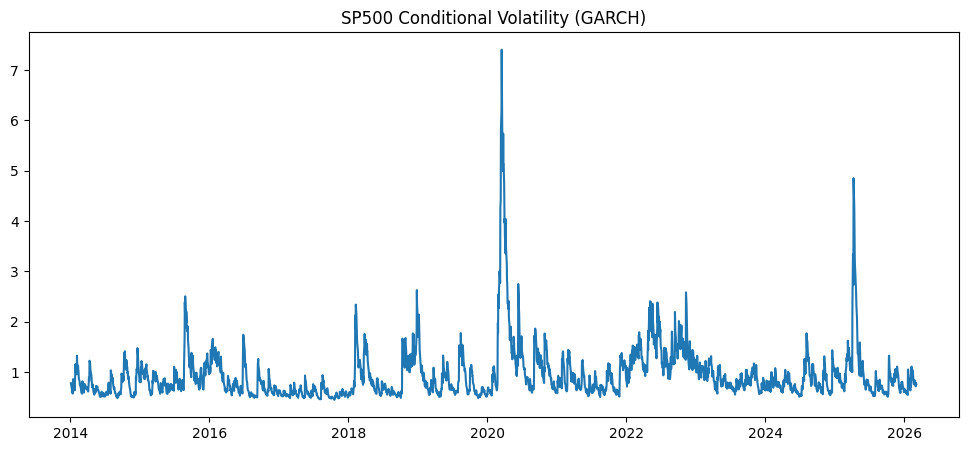

In [6]:
plt.figure(figsize=(12,5))

plt.plot(result_sp500.conditional_volatility)
plt.title("SP500 Conditional Volatility (GARCH)")
plt.show()

### Conditional Volatility

The GARCH model captures time-varying volatility and volatility clustering.

Periods of market stress correspond to spikes in conditional volatility.

In [7]:
garch_btc = arch_model(
    btc["log_return"] * 100,
    vol="Garch",
    p=1,
    q=1
)

result_btc = garch_btc.fit()

print(result_btc.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 29355.288562225374
Iteration:      2,   Func. Count:     17,   Neg. LLF: 28724.507555180004
Iteration:      3,   Func. Count:     24,   Neg. LLF: 41649.64398941818
Iteration:      4,   Func. Count:     32,   Neg. LLF: 12777.676468181446
Iteration:      5,   Func. Count:     39,   Neg. LLF: 10866.322917596095
Iteration:      6,   Func. Count:     45,   Neg. LLF: 10851.644340351035
Iteration:      7,   Func. Count:     50,   Neg. LLF: 10851.642415183931
Iteration:      8,   Func. Count:     55,   Neg. LLF: 10851.641225556521
Iteration:      9,   Func. Count:     60,   Neg. LLF: 10851.641221008194
Iteration:     10,   Func. Count:     64,   Neg. LLF: 10851.641221007703
Optimization terminated successfully    (Exit mode 0)
            Current function value: 10851.641221008194
            Iterations: 10
            Function evaluations: 64
            Gradient evaluations: 10
                     Constant Mean - GARCH Model Results     

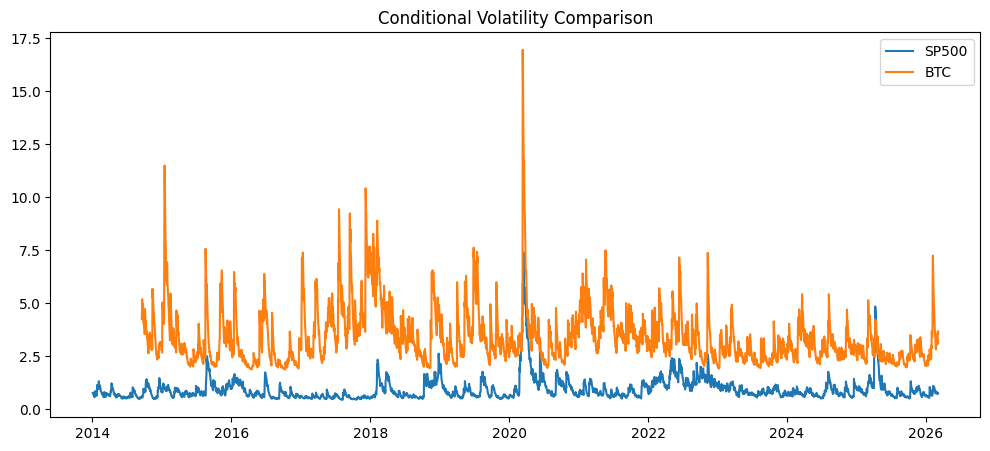

In [8]:
plt.figure(figsize=(12,5))

plt.plot(result_sp500.conditional_volatility, label="SP500")
plt.plot(result_btc.conditional_volatility, label="BTC")

plt.legend()
plt.title("Conditional Volatility Comparison")
plt.show()

In [9]:
forecast = result_sp500.forecast(horizon=5)

print(forecast.variance.tail())

                 h.1       h.2       h.3      h.4       h.5
Date                                                       
2026-03-06  0.850377  0.861803  0.872836  0.88349  0.893778
